# Soal No. 1

Debit titik 1: 9.00 m^3/s
Debit titik 2: 7.50 m^3/s
Debit titik 3: 9.07 m^3/s
Debit rata-rata: 8.52 m^3/s


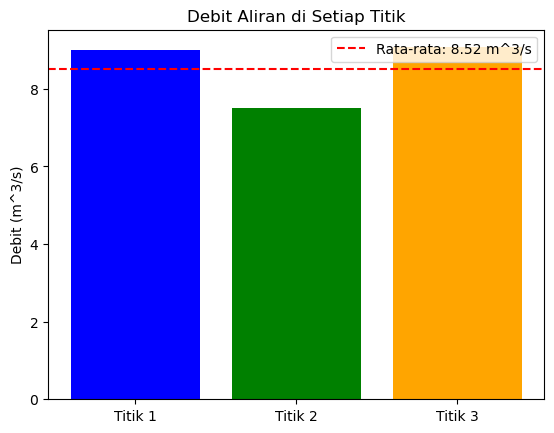

In [1]:
# Bag. a: Menghitung debit rata-rata aliran

import matplotlib.pyplot as plt
import numpy as np

# Fungsi untuk menghitung debit
# Debit (Q) = l * d * v
def hitung_debit(lebar, kedalaman, kecepatan):
    return lebar * kedalaman * kecepatan

# Data titik 1, 2, dan 3
l1, d1, v1 = 2.0, 1.5, 3.0  # lebar, kedalaman, kecepatan untuk titik 1
l2, d2, v2 = 2.5, 1.2, 2.5  # lebar, kedalaman, kecepatan untuk titik 2
l3, d3, v3 = 1.8, 1.8, 2.8  # lebar, kedalaman, kecepatan untuk titik 3

# Hitung debit untuk setiap titik
Q1 = hitung_debit(l1, d1, v1)
Q2 = hitung_debit(l2, d2, v2)
Q3 = hitung_debit(l3, d3, v3)

# Hitung debit rata-rata
Q_avg = (Q1 + Q2 + Q3) / 3

# Cetak hasil
print(f"Debit titik 1: {Q1:.2f} m^3/s")
print(f"Debit titik 2: {Q2:.2f} m^3/s")
print(f"Debit titik 3: {Q3:.2f} m^3/s")
print(f"Debit rata-rata: {Q_avg:.2f} m^3/s")

# Visualisasi grafik
labels = ["Titik 1", "Titik 2", "Titik 3"]
values = [Q1, Q2, Q3]

plt.bar(labels, values, color=['blue', 'green', 'orange'])
plt.axhline(y=Q_avg, color='red', linestyle='--', label=f"Rata-rata: {Q_avg:.2f} m^3/s")
plt.title("Debit Aliran di Setiap Titik")
plt.ylabel("Debit (m^3/s)")
plt.legend()
plt.show()

In [2]:
# Bag. b: Menghitung kedalaman sumur (H)

import numpy as np

# Debit rata-rata (m^3/s)
Q_avg = 0.5

# Konversi debit rata-rata ke m^3/jam
Q_avg_m3_per_hour = Q_avg * 3600
print(f"{Q_avg_m3_per_hour} m^3/jam")

# Parameter untuk menghitung kedalaman sumur (H)
omega = 5  # konstanta omega
r = 3  # radius sumur (m)
K = 0.02  # permeabilitas tanah (m/jam)

# Hitung kedalaman sumur (H)
H = Q_avg_m3_per_hour / (omega * np.pi * r * K)
print(f"{H} m")

1800.0 m^3/jam
1909.8593171027442 m


In [3]:
# Bag. c: Menghitung banyaknya sumur (n)

H_total = 1900  # kedalaman maks (m)
H_standar = 5  # kedalaman sumur yang ditentukan (m)

# Maka banyaknya sumur
n_sumur = H_total / H_standar
print(f"{n_sumur} sumur")


380.0 sumur


# Soal No. 2: Control Modul 1_Transfer Functions with Python

H1(s) = 
   5
-------
6 s + 1

Hpade(s) = 
-s^5 + 10 s^4 - 46.67 s^3 + 124.4 s^2 - 186.7 s + 124.4
-------------------------------------------------------
s^5 + 10 s^4 + 46.67 s^3 + 124.4 s^2 + 186.7 s + 124.4

H(s) = 
    -5 s^5 + 50 s^4 - 233.3 s^3 + 622.2 s^2 - 933.3 s + 622.2
-----------------------------------------------------------------
6 s^6 + 61 s^5 + 290 s^4 + 793.3 s^3 + 1244 s^2 + 933.3 s + 124.4



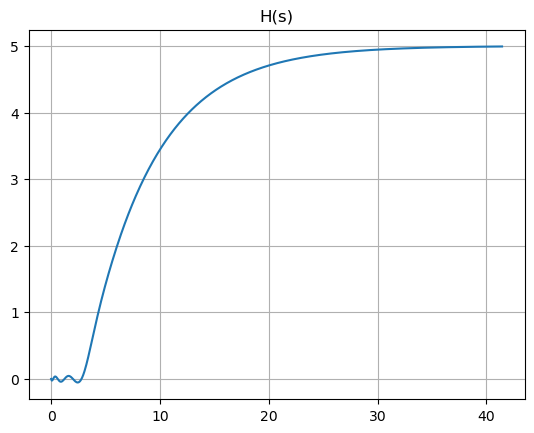

In [4]:
# Bag. a: Transfer function 1st order with time delay

import numpy as np
import matplotlib.pyplot as plt
import control

K = 5
T = 6

num = np.array ([K])
den = np.array ([T , 1])

H1 = control.tf(num , den)
print ('H1(s) =', H1)

Tau = 3
N = 5 # Order of the Approximation
[num_pade,den_pade] = control.pade(Tau,N)
Hpade = control.tf(num_pade,den_pade)
print ('Hpade(s) =', Hpade)

H = control.series(H1, Hpade)
print ('H(s) =', H)

t, y = control.step_response(H)

plt.plot(t,y)
plt.title("H(s)")
plt.grid()

H(s) = 
      2
-------------
s^2 + 6 s + 2

p = [-5.64575131+0.j -0.35424869+0.j]


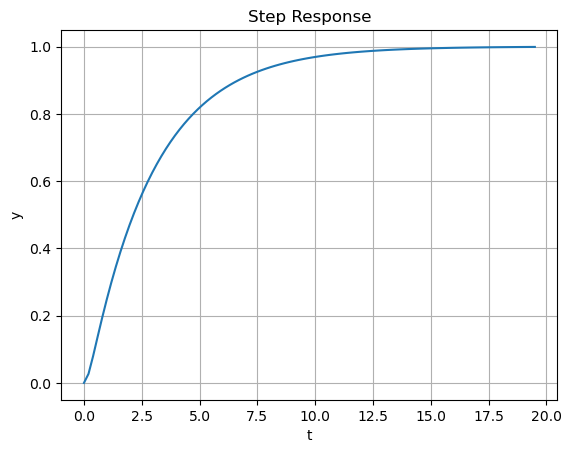

In [6]:
# Bag. b: Transfer function 2nd order

# Import library
import control
import numpy as np
import matplotlib.pyplot as plt

# Define Transfer Function
num = np.array([2])
den = np.array([1 , 6, 2])

H = control.tf(num , den)
print ('H(s) =', H)

# Poles
p = control.pole(H)
print ('p =', p)

# Step Response
t, y = control.step_response(H)

# Plotting
plt.plot(t, y)
plt.title("Step Response")
plt.xlabel("t")
plt.ylabel("y")
plt.grid()
plt.show()


# Soal No. 3: Control Modul 2_State Space Models with Python

p = [-5.64575131+0.j -0.35424869+0.j]


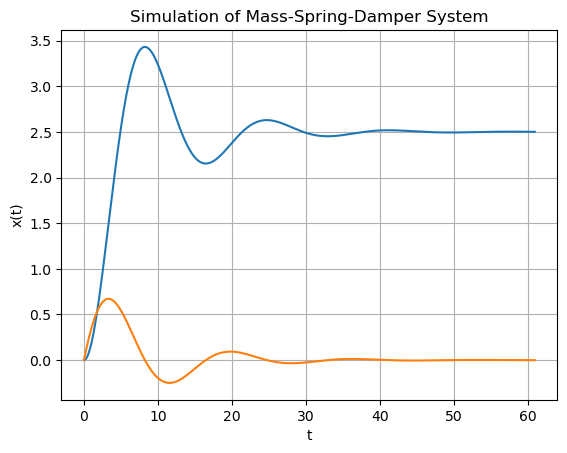

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# Parameters defining the system
c = 6 # Damping constant
k = 4 # Stiffness of the spring
m = 25 # Mass
F = 10 # Force
Ft = np.ones(610)*F

# Simulation Parameters
tstart = 0
tstop = 60
increment = 0.1
t = np.arange(tstart,tstop+1,increment)

# System matrices
A = [[0, 1], [-k/m, -c/m]]
B = [[0], [1/m]]
C = [[1, 0]]
sys = sig.StateSpace(A, B, C, 0)

# Poles
p = control.pole(H)
print ('p =', p)

# Step response for the system
t, y, x = sig.lsim(sys, Ft, t)
x1 = x[:,0]
x2 = x[:,1]
plt.plot(t, x1, t, x2)

#plt.plot(t, y)
plt.title('Simulation of Mass-Spring-Damper System')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid()
plt.show()

# Soal No. 4: Control Modul 3_Frequency Response with Python

H(s) = 
   2
-------
5 s + 1



(array([1.99750468, 1.99748161, 1.99745833, 1.99743483, 1.99741112,
        1.99738719, 1.99736303, 1.99733866, 1.99731406, 1.99728923,
        1.99726418, 1.99723889, 1.99721337, 1.99718761, 1.99716162,
        1.99713539, 1.99710891, 1.99708219, 1.99705523, 1.99702801,
        1.99700055, 1.99697283, 1.99694485, 1.99691662, 1.99688813,
        1.99685937, 1.99683035, 1.99680107, 1.99677151, 1.99674168,
        1.99671157, 1.99668119, 1.99665053, 1.99661959, 1.99658836,
        1.99655684, 1.99652503, 1.99649293, 1.99646053, 1.99642784,
        1.99639484, 1.99636154, 1.99632793, 1.99629401, 1.99625978,
        1.99622524, 1.99619038, 1.99615519, 1.99611969, 1.99608385,
        1.99604769, 1.99601119, 1.99597436, 1.99593718, 1.99589967,
        1.99586181, 1.9958236 , 1.99578504, 1.99574612, 1.99570685,
        1.99566721, 1.99562721, 1.99558685, 1.99554611, 1.99550499,
        1.9954635 , 1.99542163, 1.99537937, 1.99533672, 1.99529368,
        1.99525025, 1.99520641, 1.99516217, 1.99

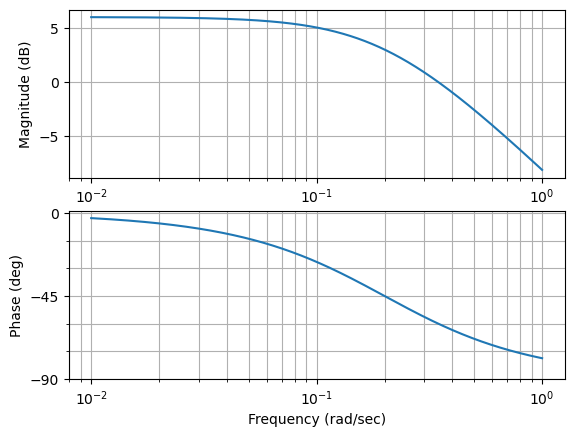

In [8]:
# Bag. a

import numpy as np
import control
num = np.array([2])
den = np.array([5 , 1])
H = control.tf(num , den)
print ('H(s) =', H)
control.bode_plot(H, dB=True)

H(s) = 
      7
-------------
s^2 + 5 s + 1



(array([6.99196382e+00, 6.96801994e+00, 6.92865298e+00, ...,
        6.99475824e-04, 6.99336082e-04, 6.99196382e-04]),
 array([-0.04996338, -0.09970827, -0.14902209, ..., -3.09161929,
        -3.09162428, -3.09162927]),
 array([1.000e-02, 2.000e-02, 3.000e-02, ..., 9.998e+01, 9.999e+01,
        1.000e+02]))

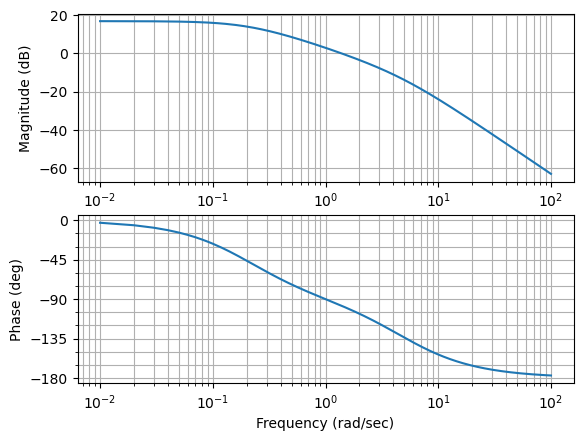

In [9]:
# bag. b
import numpy as np
import control

# Transfer Function
num = np.array([7])
den = np.array([1, 5, 1])
H = control.tf(num , den)
print ('H(s) =', H)

# Frequencies
w_start = 0.01
w_stop = 100
step = 0.01
N = int ((w_stop-w_start )/step) + 1
w = np.linspace (w_start , w_stop , N)

# Bode Plot
control.bode_plot(H, w, dB=True)

# Soal No. 5_Control Modul 4_Stability Analysis of Control Systems with Python

Hp(s) = 
   2
-------
3 s + 1

Hc(s) = 
1.25 s + 0.5
------------
   2.5 s

Hm(s) = 
    1
---------
1.5 s + 1

Hf(s) = 
    1
---------
1.5 s + 1

L(s) = 
              2.5 s + 1
--------------------------------------
16.88 s^4 + 28.12 s^3 + 15 s^2 + 2.5 s

T(s) = 
               2.5 s + 1
----------------------------------------
16.88 s^4 + 28.12 s^3 + 15 s^2 + 5 s + 1

poles =  [-1.02766326+0.j         -0.41443398+0.j         -0.11228471+0.35571268j
 -0.11228471-0.35571268j]
wc = 0.31 rad/s
w180 = 0.62 rad/s
GM = 3.26
GM = 10.27 dB
PM = 35.51 deg
Kc = 1.63


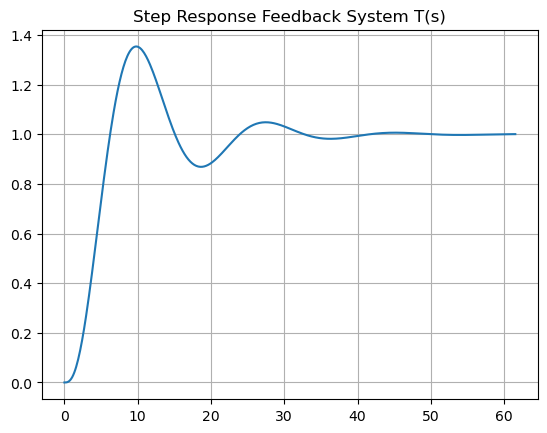

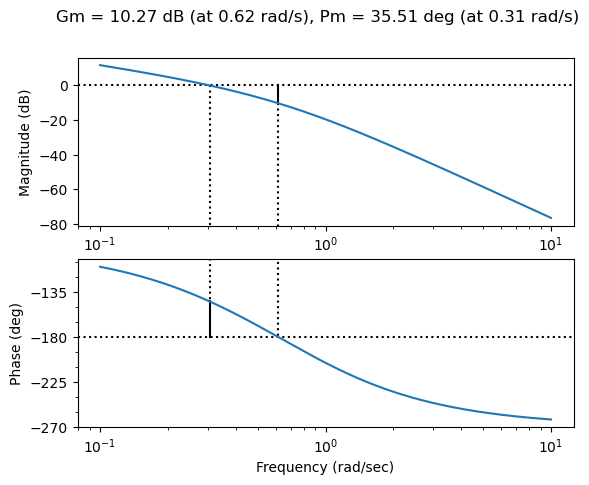

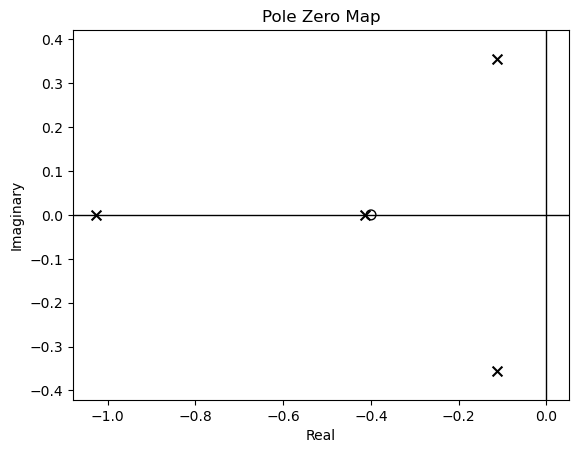

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import control

# Transfer Function Process
K = 2; T = 3
num_p = np.array ([K])
den_p = np.array ([T , 1])
Hp = control.tf(num_p , den_p)
print ('Hp(s) =', Hp)

# Transfer Function PI Controller
Kp = 0.5
Ti = 2.5
num_c = np.array ([Kp*Ti, Kp])
den_c = np.array ([Ti , 0])
Hc = control.tf(num_c, den_c)
print ('Hc(s) =', Hc)

# Transfer Function Measurement
Tm = 1.5
num_m = np.array ([1])
den_m = np.array ([Tm , 1])
Hm = control.tf(num_m , den_m)
print ('Hm(s) =', Hm)

# Transfer Function Lowpass Filter
Tf = 1.5
num_f = np.array ([1])
den_f = np.array ([Tf , 1])
Hf = control.tf(num_f , den_f)
print ('Hf(s) =', Hf)

# The Loop Transfer function
L = control.series(Hc, Hp, Hf, Hm)
print ('L(s) =', L)

# Tracking transfer function
T = control.feedback(L,1)
print ('T(s) =', T)

# Step Response Feedback System (Tracking System)
t, y = control.step_response(T)
plt.figure(1)
plt.plot(t,y)
plt.title("Step Response Feedback System T(s)")
plt.grid()

# Bode Diagram with Stability Margins
plt.figure(2)
control.bode(L, dB=True, deg=True, margins=True)

# Poles and Zeros
plt.figure(3)
control.pzmap(T)
p = control.pole(T)
z = control.zero(T)
print("poles = ", p)

# Calculating stability margins and crossover frequencies
gm , pm , w180 , wc = control.margin(L)

# Convert gm to Decibel
gmdb = 20 * np.log10(gm)
print("wc =", f'{wc:.2f}', "rad/s")
print("w180 =", f'{w180:.2f}', "rad/s")
print("GM =", f'{gm:.2f}')
print("GM =", f'{gmdb:.2f}', "dB")
print("PM =", f'{pm:.2f}', "deg")

# Find when Sysem is Marginally Stable (Kritical Gain - Kc)
Kc = Kp*gm
print("Kc =", f'{Kc:.2f}')